In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow  

df = pd.read_excel("Sample - Superstore 2019.xls")
print("shape:", df.shape)
df.head()


shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [4]:
df_raw = df.copy()
df_raw.shape

(9994, 21)

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

In [6]:
# Drop unnecessary columns
def drop_unnecessary_columns(data):
    columns_to_drop = ["Row ID"]
    data = data.drop(columns=columns_to_drop)
    return data
df_raw = drop_unnecessary_columns(df_raw)

In [7]:
df_raw.shape

(9994, 20)

In [8]:
df_raw[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df_raw.describe(include="str")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2019-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [10]:
# Optimize data types (convert to datetime and category to save memory)
def convrert_data_types(data):
    date_cols = ["Order Date", "Ship Date"]
    for col in date_cols:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col])
    str_cols = data.select_dtypes("str").columns.tolist()
    for col in str_cols:
        if len(data[col].unique()) <= 50:
           data[col] = data[col].astype("category")

    return data
df_raw = convrert_data_types(df_raw)

In [11]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   str           
 1   Order Date      9994 non-null   datetime64[us]
 2   Ship Date       9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   category      
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Segment         9994 non-null   category      
 7   Country/Region  9994 non-null   category      
 8   City            9994 non-null   str           
 9   State           9994 non-null   category      
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   category      
 12  Product ID      9994 non-null   str           
 13  Category        9994 non-null   category      
 14  Sub-Category    9994 non-null   category      
 15  Product Name   

In [12]:
print(df_raw.isnull().sum())

Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64


In [13]:
missing_postal = df_raw[df_raw["Postal Code"].isnull()][["Country/Region", "City", "State", "Region"]]


print(missing_postal)

     Country/Region        City    State Region
2234  United States  Burlington  Vermont   East
5274  United States  Burlington  Vermont   East
8798  United States  Burlington  Vermont   East
9146  United States  Burlington  Vermont   East
9147  United States  Burlington  Vermont   East
9148  United States  Burlington  Vermont   East
9386  United States  Burlington  Vermont   East
9387  United States  Burlington  Vermont   East
9388  United States  Burlington  Vermont   East
9389  United States  Burlington  Vermont   East
9741  United States  Burlington  Vermont   East


In [14]:
def handle_missing_data(data):
    if "Postal Code" in data.columns:
        data["Postal Code"] = data["Postal Code"].astype("str")
        data["Postal Code"] = data["Postal Code"].replace(['nan', 'Nan', 'NaN'], '05401').fillna("05401")

    return data
df_raw = handle_missing_data(df_raw)

In [15]:
print(df_raw.isnull().sum())

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [16]:
print("Duplicates:", df_raw.duplicated().sum())

Duplicates: 1


In [17]:
def remove_duplicates(data):
    data = data.drop_duplicates()
    return data 
df_raw = remove_duplicates(df_raw)

In [18]:
print("Duplicates:", df_raw.duplicated().sum())

Duplicates: 0


In [19]:
# Selecting all the 'category' columns
category_col = df_raw.select_dtypes('category').columns.tolist()
category_col

['Ship Mode',
 'Segment',
 'Country/Region',
 'State',
 'Region',
 'Category',
 'Sub-Category']

In [20]:
for col in category_col:
    print(col, "->", df[col].unique())

Ship Mode -> <ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
Segment -> <ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Country/Region -> <ArrowStringArray>
['United States']
Length: 1, dtype: str
State -> <ArrowStringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',     

In [21]:
# Clean and standardize text columns (strip extra spaces and apply title case)
def clean_text_columns(data):
    string_cols = data.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in string_cols:
        data[col] = data[col].str.strip().str.title()
    return data
df_raw = clean_text_columns(df_raw)

C:\Users\Reem\AppData\Local\Temp\ipykernel_20240\3736783420.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = data.select_dtypes(include=['category', 'object']).columns.tolist()


In [22]:
df_raw["Segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [23]:
# 1. Name Check: Group by Product Name and count unique Product IDs
name_check = df_raw.groupby('Product Name')['Product ID'].nunique()
names_with_multiple_ids = name_check[name_check > 1]

print(f"Number of Product Names with multiple IDs: {len(names_with_multiple_ids)}")
if len(names_with_multiple_ids) > 0:
    print("Sample of problematic Product Names:\n", names_with_multiple_ids.head())

print("-" * 40)

# 2. ID Check: Group by Product ID and count unique Product Names
id_check = df_raw.groupby('Product ID')['Product Name'].nunique()
ids_with_multiple_names = id_check[id_check > 1]

print(f"Number of Product IDs with multiple Names: {len(ids_with_multiple_names)}")
if len(ids_with_multiple_names) > 0:
    print("Sample of problematic Product IDs:\n", ids_with_multiple_names.head())

Number of Product Names with multiple IDs: 16
Sample of problematic Product Names:
 Product Name
#10- 4 1/8" X 9 1/2" Recycled Envelopes    2
Avery Non-Stick Binders                    2
Easy-Staple Paper                          8
Eldon Wave Desk Accessories                2
Ki Adjustable-Height Table                 2
Name: Product ID, dtype: int64
----------------------------------------
Number of Product IDs with multiple Names: 32
Sample of problematic Product IDs:
 Product ID
Fur-Bo-10002213    2
Fur-Ch-10001146    2
Fur-Fu-10001473    2
Fur-Fu-10004017    2
Fur-Fu-10004091    2
Name: Product Name, dtype: int64


In [24]:
# 1. Unify Product Names for each Product ID (maps the first occurring name to the ID)
id_to_name_mapping = df_raw.groupby('Product ID')['Product Name'].first()
df_raw['Product Name'] = df_raw['Product ID'].map(id_to_name_mapping)

# 2. Unify Product IDs for each Product Name (maps the first occurring ID to the name)
name_to_id_mapping = df_raw.groupby('Product Name')['Product ID'].first()
df_raw['Product ID'] = df_raw['Product Name'].map(name_to_id_mapping)

# 3. Final verification to ensure data consistency (expecting 0 problems left)
final_name_check = df_raw.groupby('Product Name')['Product ID'].nunique()
final_id_check = df_raw.groupby('Product ID')['Product Name'].nunique()

print(f"Problems left (Names with multiple IDs): {len(final_name_check[final_name_check > 1])}")
print(f"Problems left (IDs with multiple Names): {len(final_id_check[final_id_check > 1])}")

Problems left (Names with multiple IDs): 0
Problems left (IDs with multiple Names): 0


--- Visualizing Sales Distribution (Boxplots) ---


C:\Users\Reem\AppData\Local\Temp\ipykernel_20240\4041378766.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(segment_sales["Sales"], vert=False)


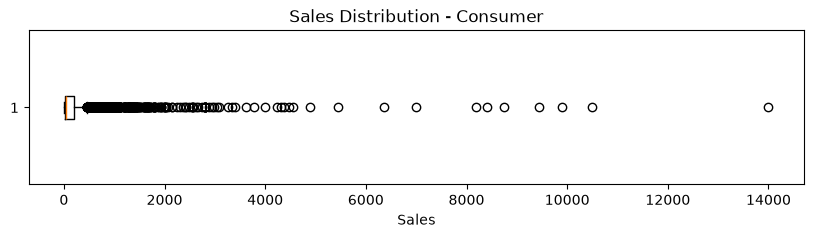

C:\Users\Reem\AppData\Local\Temp\ipykernel_20240\4041378766.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(segment_sales["Sales"], vert=False)


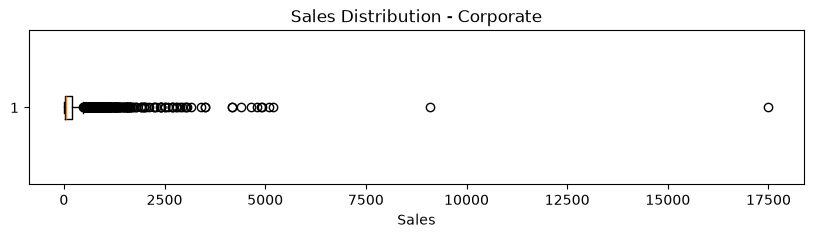

C:\Users\Reem\AppData\Local\Temp\ipykernel_20240\4041378766.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(segment_sales["Sales"], vert=False)


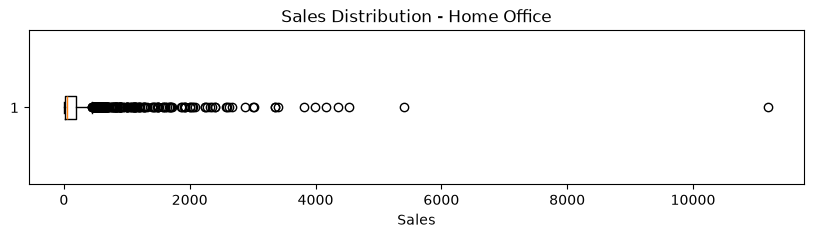

In [25]:
import matplotlib.pyplot as plt

print("--- Visualizing Sales Distribution (Boxplots) ---")
segments = ['Consumer', 'Corporate', 'Home Office']

for segment in segments:
    # Filter for positive profit to analyze successful orders
    mask = (df_raw["Segment"] == segment) & (df_raw["Profit"] >= 0)
    segment_sales = df_raw[mask]
    
    plt.figure(figsize=(10, 2))
    plt.boxplot(segment_sales["Sales"], vert=False)
    plt.title(f"Sales Distribution - {segment}")
    plt.xlabel("Sales")
    plt.show()

In [26]:
print("--- Detecting Outliers (IQR Method per Segment) ---")

df_raw['Outlier_Flag'] = False
columns_to_check = ['Sales', 'Profit']

for col in columns_to_check:
    print(f"\nAnalyzing outliers for {col}:")
    
    # Calculate IQR bounds per segment
    q1 = df_raw.groupby('Segment')[col].transform(lambda x: x.quantile(0.25))
    q3 = df_raw.groupby('Segment')[col].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Flag the outliers
    mask = (df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)
    df_raw.loc[mask, 'Outlier_Flag'] = True
    
    # Print breakdown per segment
    segments = df_raw['Segment'].unique()
    for segment in segments:
        segment_outliers = ((df_raw['Segment'] == segment) & mask).sum()
        print(f"  - {segment}: {segment_outliers} outliers")

--- Detecting Outliers (IQR Method per Segment) ---

Analyzing outliers for Sales:
  - Consumer: 573 outliers
  - Corporate: 379 outliers
  - Home Office: 218 outliers

Analyzing outliers for Profit:
  - Consumer: 971 outliers
  - Corporate: 585 outliers
  - Home Office: 334 outliers


In [27]:
def run_sanity_checks(data):
    print("--- Running Sanity Checks ---")
    
    # Range sanity check: Discount should logically fall between 0 and 1
    assert data["Discount"].min() >= 0 and data["Discount"].max() <= 1, "Error: Discount is out of logical bounds (0 to 1)!"
    
    # Business signal check: Negative profit is expected (orders sold at a loss)
    loss_orders_count = (data["Profit"] < 0).sum()
    
    print("Sanity checks passed successfully!")
    print(f"Discount Range: {data['Discount'].min()} to {data['Discount'].max()}")
    print(f"Business Note: {loss_orders_count} orders were sold at a loss.")
    
    return data

df_raw = run_sanity_checks(df_raw)

--- Running Sanity Checks ---
Sanity checks passed successfully!
Discount Range: 0.0 to 0.8
Business Note: 1870 orders were sold at a loss.


In [30]:
df_raw.to_parquet("Sample - Superstore 2019_clean.parquet", engine="pyarrow", index=False)